In [3]:
from functools import partial
import os
import argparse
import yaml
import numpy as np
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from scipy.signal import wiener
# from skimage import color, data, restoration
import math 
import time


from guided_diffusion.condition_methods import get_conditioning_method
from guided_diffusion.measurements import get_noise, get_operator
from guided_diffusion.unet import create_model
from guided_diffusion.gaussian_diffusion import create_sampler

##### For autofocusing ==================================
from guided_diffusion.demotion import autofocusing
from torch.fft import fftshift, ifftshift, fftn, ifftn

Ft = lambda x : torch.fft.fftshift(torch.fft.fft2(x))
IFt = lambda x : torch.fft.ifftn(torch.fft.ifftshift(x))
###=======================================================


# ############# For undersampling ##########

from guided_diffusion.mask_set import create_mask

# ########################################

import sys
sys.path.insert(0,'/home/projects/medimg/arunima/Arunima/diffusion_codes/DPS_using_ddim/AutoDPS/data')
from data import * 
# from data.load_brats import load_data   ## added

from load_hcp_h5 import load_data

from util.img_utils import clear_color, mask_generator
from util.logger import get_logger


def load_yaml(file_path: str) -> dict:
    with open(file_path) as f:
        config = yaml.load(f, Loader=yaml.FullLoader)
    return config

def normalize(image):
    return (image - image.min())/(image.max()-image.min())



In [9]:
model_config_path = '/home/projects/medimg/arunima/Arunima/diffusion_codes/DPS_using_ddim/AutoDPS/configs/model_config.yaml'
diffusion_config_path = '/home/projects/medimg/arunima/Arunima/diffusion_codes/DPS_using_ddim/AutoDPS/configs/diffusion_config.yaml'
task_config_path = '/home/projects/medimg/arunima/Arunima/diffusion_codes/DPS_using_ddim/AutoDPS/configs/motion_artifact_config.yaml'
save_dir = '/home/projects/medimg/arunima/Arunima/sample_notebook'

In [10]:
# logger
logger = get_logger()

# Device setting
device_str = f"cuda:{0}" if torch.cuda.is_available() else 'cpu'
logger.info(f"Device set to {device_str}.")
device = torch.device(device_str)  

# Load configurations
model_config = load_yaml(model_config_path)
model_config['model_path'] = '/home/projects/medimg/arunima/Arunima/checkpoint/hcp_checkpoint/ema_0.9999_200000.pt'
# print(model_config)
diffusion_config = load_yaml(diffusion_config_path)
task_config = load_yaml(task_config_path)

avg_psnr = []
avg_psnr_fil=[]

# Load model
model = create_model(**model_config)
model = model.to(device)
model.eval()

# Prepare Operator and noise
measure_config = task_config['measurement']
operator = get_operator(device=device, **measure_config['operator'])
noiser = get_noise(**measure_config['noise'])
logger.info(f"Operation: {measure_config['operator']['name']} / Noise: {measure_config['noise']['name']}")

# Prepare conditioning method
cond_config = task_config['conditioning']
cond_method = get_conditioning_method(cond_config['method'], operator, noiser,measure_config['operator']['name'],\
                                      **cond_config['params'])
measurement_cond_fn = cond_method.conditioning
logger.info(f"Conditioning method : {task_config['conditioning']['method']}")

# Load diffusion sampler
sampler = create_sampler(**diffusion_config) 
if diffusion_config['sampler']=='ddim':
    sample_fn = partial(sampler.ddim_sample_loop, model=model, measurement_cond_fn=measurement_cond_fn)
else:
    sample_fn = partial(sampler.p_sample_loop, model=model, measurement_cond_fn=measurement_cond_fn)

#  Working directory
save_path = os.path.join(save_dir, measure_config['operator']['name'])


# Prepare dataloader

h5_path = '/home/projects/medimg/arunima/Arunima/dataset/hcp_h5'
mode = 'test'


dataset = load_data(h5_path,mode = mode) ## FOR HCP
loader = torch.utils.data.DataLoader(dataset,batch_size=1,shuffle= False ,num_workers = 0)


# In case of undersampling, we need to generate a mask 
if measure_config['operator']['name'] == 'undersampling' or measure_config['operator']['name'] =='motion+undersampling':

    mask_type = measure_config['operator']['masktype']
    acc = measure_config['operator']['accfactor']
    a = torch.ones((1,1,256,256))
    m=create_mask(mask_type,a.shape,acc).to(device)

# Do Inference

for i,img in enumerate(loader):


    logger.info(f"Inference for image {i}")

    ref_img = img[0]
    mask = img[1]
    vol = int(img[3][0])
    slice = int(img[4][0])


    os.makedirs(save_dir, exist_ok=True)

    out_path = save_path + f'/image_{vol}_{slice}'

    for img_dir in ['input', 'recon', 'progress',\
                    'degradation','clean_image',\
                    'norm_grad','x_0_hat','filtered','mask']:
        os.makedirs(os.path.join(out_path, img_dir), exist_ok=True)

    ref_img = ref_img.to(device)

    #  In case of undersampling,
    if measure_config['operator'] ['name'] == 'undersampling':

#             Forward measurement model (Ax)
        y = operator.forward(ref_img, mask=m)
        y_n = noiser(y)


    elif measure_config['operator']['name'] == 'motion+undersampling':


        #### Forward model (Ax) such that A = MOTION-->UNDERSAMPLE
        clean = ref_img


        corrupted_ksp,shift_vector,rot_vectorgt = operator.forward_motion(ref_img)
        y1 = abs(IFt(corrupted_ksp))


        y = operator.forward_undersample(y1[None,:,:,:], mask=m)
        corrupted_ksp_ = Ft(y)

        if noiser.sigma:
                y = noiser(y)
                corrupted_ksp_ = Ft(y)[:,:,:,:]


        ## Applying Autofocusing ####

        filtered_image,shift_vec,alpha_hat = autofocusing(corrupted_ksp_)
        np.savez(os.path.join(out_path, 'filtered', 'image'), clear_color(filtered_image))
        plt.imsave(os.path.join(out_path, 'filtered', 'image.png') , clear_color(filtered_image), cmap='gray')


        ksp_sub_optimal = Ft(filtered_image)
        ycr = corrupted_ksp_.abs() ### corrupted ksp
        yf = ksp_sub_optimal.abs() ### AF filtered ksp
        yfinv = torch.reciprocal(yf)

        anglecr = (1j*corrupted_ksp_.angle()).exp()
        anglef = (-1j*ksp_sub_optimal.angle()).exp()

        new_lhs = yfinv*anglef*ycr*anglecr
        new_phase_shift = new_lhs.angle() ##### estimated theta: theta_tilde

        #############################



        ############ Using GT ####################
        x_shifts = shift_vector[0]
        y_shifts = shift_vector[1]
        x_shape, y_shape = corrupted_ksp.shape[-2:]
        # Translation
        phase_shiftgt = -2 * math.pi * (
            x_shifts * torch.linspace(0, 1, x_shape)[None, :, None] + 
            y_shifts * torch.linspace(0, 1, y_shape)[None, None, :])[0]
        ###########################################

    else: 

        # Forward measurement model (Ax + n)
        clean = ref_img

        corrupted_ksp,shift_vector,rot_vectorgt= operator.forward(ref_img)  ### Ax
        y1 = IFt(corrupted_ksp)
        y = abs(y1)

        if noiser.sigma:
                y = noiser(y)
                corrupted_ksp = Ft(y)


        ########################### phase gt ###################################

        x_shifts = shift_vector[0]
        y_shifts = shift_vector[1]
        x_shape, y_shape = corrupted_ksp.shape[-2:]
        # Translation
        phase_shiftgt = -2 * math.pi * (
            x_shifts * torch.linspace(0, 1, x_shape)[None, :, None] + 
            y_shifts * torch.linspace(0, 1, y_shape)[None, None, :])[0]

        ######################################################################

        filtered_image,shift_vec,alpha_hat = autofocusing(corrupted_ksp)

        np.savez(os.path.join(out_path, 'filtered', 'image'), clear_color(filtered_image))
        plt.imsave(os.path.join(out_path, 'filtered', 'image.png') , clear_color(filtered_image), cmap='gray')

        ksp_sub_optimal = Ft(filtered_image)
        ycr = corrupted_ksp.abs() ### corrupted ksp
        yf = ksp_sub_optimal.abs() ### AF filtered ksp
        yfinv = torch.reciprocal(yf)

        anglecr = (1j*corrupted_ksp.angle()).exp()
        anglef = (-1j*ksp_sub_optimal.angle()).exp()

        new_lhs = yfinv*anglef*ycr*anglecr
        new_phase_shift = new_lhs.angle() ##### estimated theta: theta_tilde


    #### Sampling ####

    x_start = torch.randn(ref_img.shape, device=device).requires_grad_()

    if measure_config['operator']['name'] =='motion_artifact':
        sample = sample_fn(x_start=x_start,measurement=y,shift=new_phase_shift,\
                           rot=alpha_hat,noise =0,mask=None,record=True,save_root=out_path)

    if measure_config['operator']['name'] == 'undersampling':
        sample = sample_fn(x_start=x_start,measurement=y,shift=None,rot=None,\
                           noise = noiser.sigma,mask=m,record=True,save_root=out_path)

    if measure_config['operator'] ['name'] == 'motion+undersampling':
        sample = sample_fn(x_start=x_start,measurement=y,shift=new_phase_shift,rot=alpha_hat,\
                           mask=m,noise = 0,record=True,save_root=out_path)


    np.savez(os.path.join(out_path, 'degradation','image'), clear_color(y))
    plt.imsave(os.path.join(out_path , 'degradation','image.png') , clear_color(y), cmap='gray')

    np.savez(os.path.join(out_path, 'mask', 'image'), clear_color(mask))
    plt.imsave(os.path.join(out_path , 'mask','image.png') , clear_color(mask), cmap='gray')

    np.savez(os.path.join(out_path, 'recon', 'image'), clear_color(sample))
    plt.imsave(os.path.join(out_path , 'recon','image.png'), clear_color(sample), cmap='gray')

    np.savez(os.path.join(out_path, 'clean_image', 'image'), clear_color(clean))
    plt.imsave(os.path.join(out_path,'clean_image','image.png'), clear_color(clean), cmap='gray')

    del out_path
    break


2024-07-14 11:15:17,681 [DPS] >> Device set to cuda:0.
2024-07-14 11:15:17,681 [DPS] >> Device set to cuda:0.
2024-07-14 11:15:17,681 [DPS] >> Device set to cuda:0.
2024-07-14 11:15:17,681 [DPS] >> Device set to cuda:0.
2024-07-14 11:15:19,858 [DPS] >> Operation: motion_artifact / Noise: gaussian
2024-07-14 11:15:19,858 [DPS] >> Operation: motion_artifact / Noise: gaussian
2024-07-14 11:15:19,858 [DPS] >> Operation: motion_artifact / Noise: gaussian
2024-07-14 11:15:19,858 [DPS] >> Operation: motion_artifact / Noise: gaussian
2024-07-14 11:15:19,861 [DPS] >> Conditioning method : ps
2024-07-14 11:15:19,861 [DPS] >> Conditioning method : ps
2024-07-14 11:15:19,861 [DPS] >> Conditioning method : ps
2024-07-14 11:15:19,861 [DPS] >> Conditioning method : ps
2024-07-14 11:15:19,887 [DPS] >> Inference for image 0
2024-07-14 11:15:19,887 [DPS] >> Inference for image 0
2024-07-14 11:15:19,887 [DPS] >> Inference for image 0
2024-07-14 11:15:19,887 [DPS] >> Inference for image 0
100%|███████████

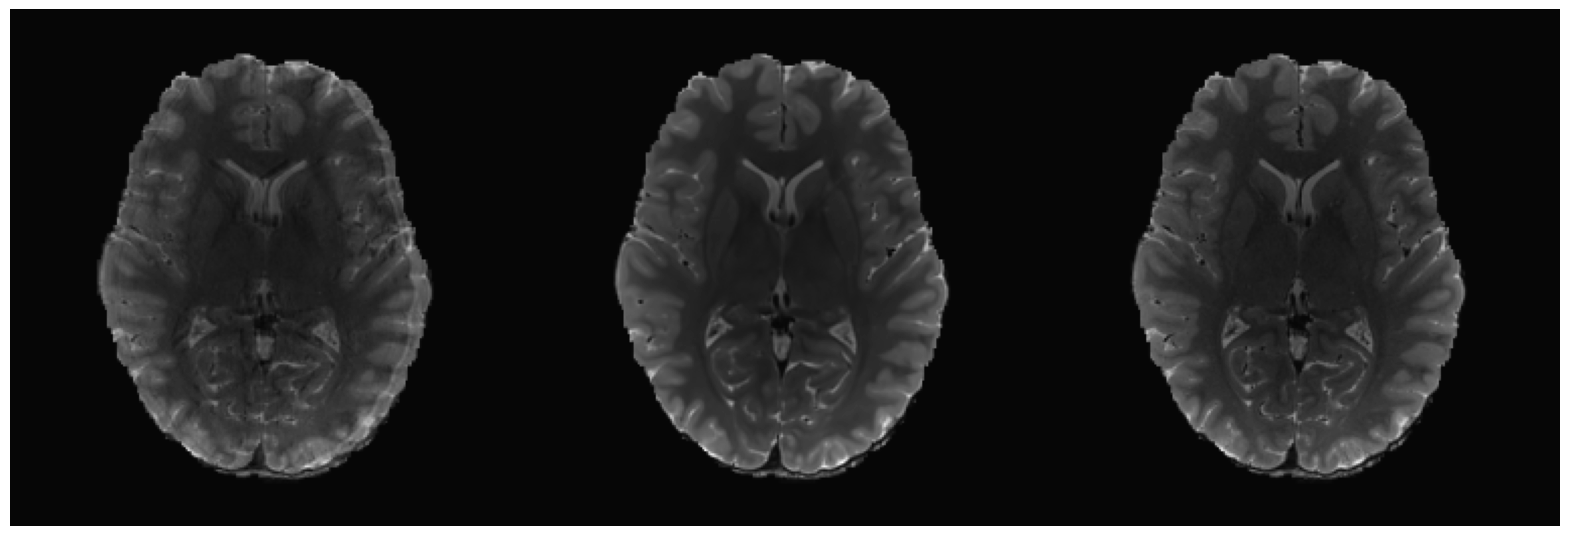

In [13]:
mask = np.load('/home/projects/medimg/arunima/Arunima/sample_notebook/motion_artifact/image_0_110/mask/image.npz')['arr_0']
clean = np.load('/home/projects/medimg/arunima/Arunima/sample_notebook/motion_artifact/image_0_110/clean_image/image.npz')['arr_0']*mask
degraded = np.load('/home/projects/medimg/arunima/Arunima/sample_notebook/motion_artifact/image_0_110/degradation/image.npz')['arr_0']*mask
autodps = np.load('/home/projects/medimg/arunima/Arunima/sample_notebook/motion_artifact/image_0_110/recon/image.npz')['arr_0']*mask

x = np.concatenate((degraded,autodps,clean),axis=1)
plt.figure(figsize=(20,20))
plt.axis('off')
plt.imshow(x,cmap='gray')

